# Testing of astar implementation

In [1]:
import numpy as np
from heapq import heappush, heappop
from matplotlib import pyplot as plt

False


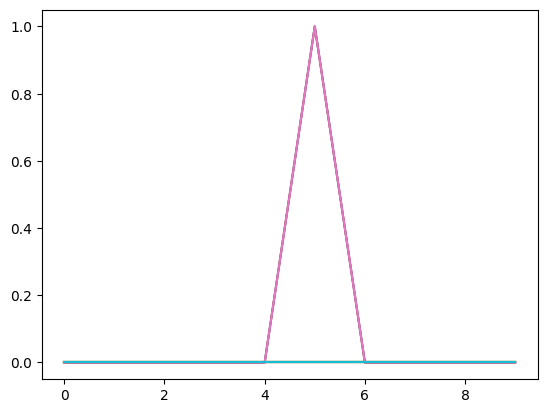

In [2]:
SIZE = (10,10)
walls = np.zeros(shape=SIZE,dtype=bool)
for i in np.arange(4,7):
    walls[5,i] = True
start = np.array([1,5])
end = np.array([8,5])
plt.plot(walls)

print(walls[*start])

3


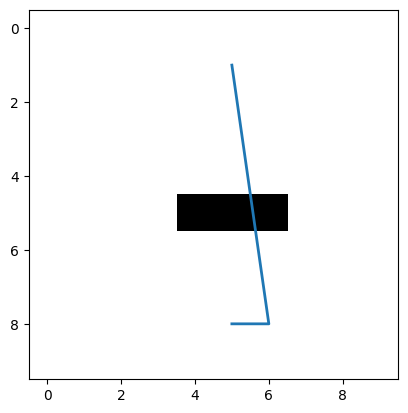

In [ ]:
DIRS = np.array([[1,0],[0,1],[-1,0],[0,-1]])
def in_range(c):
    global walls
    return c[0] >= 0 and c[0] < walls.shape[0] and c[1] >= 0 and c[1] < walls.shape[1]
    
def move(c,dir):
    new_c = c+DIRS[dir]
    return new_c

def neighborhood(c):
    global walls
    global end
    neigh = []
    for i in range(len(DIRS)):
        new_c = move(c,i)
        if in_range(new_c) and not walls[*new_c]:
            neigh.append(new_c)
    neigh.append(end + np.array([0,1]))# a one way teleport
    return neigh
        

def manhattan(a,b):
    return np.sum(np.abs(a-b))
def is_goal_reached(c):
    global end
    return manhattan(c,end) == 0

#print(in_range([0,1]))
#print(in_range([0,10]))
#print(neighborhood([6,4]))
def reconstruct_path(parent,end):
    path = [end]
    p = parent[*end]
    while p:
        path.append(np.array(p))
        try:
            p = parent[*p]
        except:
            break
    return np.array(path)

def astar(s,e,n,h,g):
    """ 
    s - start
    e - end, target position
    n - neighborhood function
    h - distance for the heuristic
    g - goal reached
    """
    # Initialize arrays
    openSet = []
    fScore = np.ones(shape=SIZE)*np.inf
    gScore = np.ones(shape=SIZE)*np.inf
    parent = {}

    # Initialize start
    heappush(openSet,(h(s,e),tuple(s)))
    fScore[*s] = 0
    gScore[*s] = h(s,e)

    while len(openSet) > 0:
        f,current = heappop(openSet)
        # is goal check
        if g(current):
            return reconstruct_path(parent,e) # return just the cost for now
        # go through neigborhood
        # evaluate f,g
        # add to open set
        #print(n(current))
        #print(openSet)
        for c in n(current):
            fScore[*c] = h(c,e)+gScore[*current] # calculate distance from end
            tmp_gscore = gScore[*current] + 1
            #print(c,tmp_gscore,gScore[*c])
            if tmp_gscore < gScore[*c]:
                parent[*c] = current
                gScore[*c] = tmp_gscore
                heappush(openSet,(fScore[*c],tuple(c)))

    pass
def dijkstra(a,b):
    return 0

path = astar(start,end,neighborhood,dijkstra,is_goal_reached)
print(len(path))
plt.imshow(walls, cmap="gray_r")
plt.plot(path[:,1], path[:,0], linewidth=2)

In [4]:
open_heap = []
heappush(open_heap, (manhattan([4,3],end), [4,3]))
heappush(open_heap, (manhattan(start,end), start))
print(open_heap)


[(np.int64(6), [4, 3]), (np.int64(7), array([1, 5]))]


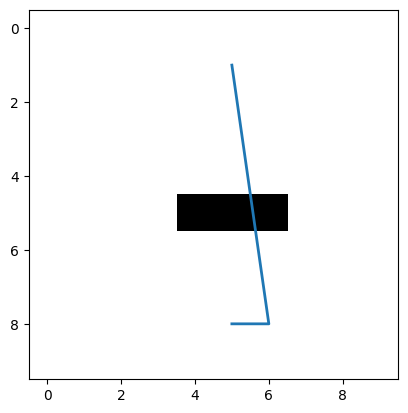

In [17]:
def astar_general(s,e,n,h,g):
    """ 
    s - start
    e - end, target position
    n - neighborhood function
    h - distance for the heuristic
    g - goal reached
    """
    # Initialize arrays
    openSet = []
    fScore = {}
    gScore = {}
    parent = {}

    # Initialize start
    heappush(openSet,(h(s,e),tuple(s)))
    fScore[*s] = 0
    gScore[*s] = h(s,e)

    while len(openSet) > 0:
        f,current = heappop(openSet)
        # is goal check
        if g(current):
            return reconstruct_path(parent,e) # return just the cost for now
        # go through neigborhood
        # evaluate f,g
        # add to open set
        for c in n(current):
            fScore[*c] = h(c,e)+gScore[*current] # calculate distance from end
            tmp_gscore = gScore[*current] + 1
            #print(c,tmp_gscore,gScore[*c])
            previous_gscore = np.inf
            try:
                previous_gscore = gScore[*c]
            except:
                pass
            if tmp_gscore < previous_gscore:
                parent[*c] = current
                gScore[*c] = tmp_gscore
                #print(c,gScore[*c],h(c,e))
                heappush(openSet,(h(c,e)+gScore[*current],tuple(c)))
path = astar_general(start,end,neighborhood,dijkstra,is_goal_reached)
plt.imshow(walls, cmap="gray_r")
plt.plot(path[:,1], path[:,0], linewidth=2)